# EX 1

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import pandas as pd
import os
import requests
import zipfile

torch.manual_seed(42);

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    else:
        assert False, 'Only zip files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def read_data_bananas(is_train=True):
    """Read the banana detection dataset images and labels."""
    data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(torchvision.io.read_image(
            os.path.join(data_dir, 'bananas_train' if is_train else
                         'bananas_val', 'images', f'{img_name}')))
        # Here `target` contains (class, upper-left x, upper-left y,
        # lower-right x, lower-right y), where all the images have the same
        # banana class (index 0)
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256

class BananasDataset(torch.utils.data.Dataset):
    """A customized dataset to load the banana detection dataset."""
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

def load_data_bananas(batch_size):
    """Load the banana detection dataset."""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter
#ex1
batch_size = 64
train_iter, _ = load_data_bananas(batch_size)
def box_corner_to_center(boxes):
    """Convert from (upper-left, lower-right) to (center, width, height)."""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    boxes = torch.stack((cx, cy, w, h), axis=-1)
    return boxes

def box_center_to_corner(boxes):
    """Convert from (center, width, height) to (upper-left, lower-right)."""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes

def multibox_prior(data, sizes, ratios):
    """Generate anchor boxes with different shapes centered on each pixel."""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1)
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)

    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height  # Scaled steps in y axis
    steps_w = 1.0 / in_width  # Scaled steps in x axis

    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),
                   sizes[0] * torch.sqrt(ratio_tensor[1:])))\
                   * in_height / in_width  # Handle rectangular inputs
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),
                   sizes[0] / torch.sqrt(ratio_tensor[1:])))
    # Divide by 2 to get half height and half width
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
                                        in_height * in_width, 1) / 2


    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1).repeat_interleave(boxes_per_pixel, dim=0)
    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)

def box_iou(boxes1, boxes2):
    """Compute pairwise IoU across two lists of anchor or bounding boxes."""
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) *
                              (boxes[:, 3] - boxes[:, 1]))
    # Shape of `boxes1`, `boxes2`, `areas1`, `areas2`: (no. of boxes1, 4),
    # (no. of boxes2, 4), (no. of boxes1,), (no. of boxes2,)
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)
    # Shape of `inter_upperlefts`, `inter_lowerrights`, `inters`: (no. of
    # boxes1, no. of boxes2, 2)
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    union_areas = areas1[:, None] + areas2 - inter_areas
    return inter_areas / union_areas

def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """Assign closest ground-truth bounding boxes to anchor boxes."""
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]

    jaccard = box_iou(anchors, ground_truth)
    # Initialize the tensor to hold the assigned ground-truth bounding box for
    # each anchor
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long,
                                  device=device)
    # Assign ground-truth bounding boxes according to the threshold
    max_ious, indices = torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)
    box_j = indices[max_ious >= iou_threshold]
    anchors_bbox_map[anc_i] = box_j
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        max_idx = torch.argmax(jaccard)  # Find the largest IoU
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx / num_gt_boxes).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
    return anchors_bbox_map

def offset_boxes(anchors, assigned_bb, eps=1e-6):
    """Transform for anchor box offsets."""
    c_anc = box_corner_to_center(anchors)
    c_assigned_bb = box_corner_to_center(assigned_bb)
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    return offset

def multibox_target(anchors, labels):
    """Label anchor boxes using ground-truth bounding boxes."""
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox(
            label[:, 1:], anchors, device)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(
            1, 4)
        # Initialize class labels and assigned bounding box coordinates with
        # zeros
        class_labels = torch.zeros(num_anchors, dtype=torch.long,
                                   device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32,
                                  device=device)

        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true]
        class_labels[indices_true] = label[bb_idx, 0].long() + 1
        assigned_bb[indices_true] = label[bb_idx, 1:]
        # Offset transformation
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    bbox_offset = torch.stack(batch_offset)
    bbox_mask = torch.stack(batch_mask)
    class_labels = torch.stack(batch_class_labels)
    return (bbox_offset, bbox_mask, class_labels)

def offset_inverse(anchors, offset_preds):
    """Predict bounding boxes based on anchor boxes with predicted offsets."""
    anc = box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    predicted_bbox = box_center_to_corner(pred_bbox)
    return predicted_bbox

def nms(boxes, scores, iou_threshold):
    """Sort confidence scores of predicted bounding boxes."""
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []  # Indices of predicted bounding boxes that will be kept
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1: break
        iou = box_iou(boxes[i, :].reshape(-1, 4),
                      boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, device=boxes.device)

def multibox_detection(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                       pos_threshold=0.009999999):
    """Predict bounding boxes using non-maximum suppression."""
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0)
        predicted_bb = offset_inverse(anchors, offset_pred)
        keep = nms(predicted_bb, conf, nms_threshold)
        # Find all non-`keep` indices and set the class to background
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]

        below_min_idx = (conf < pos_threshold)
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]
        pred_info = torch.cat((class_id.unsqueeze(1),
                               conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
    return torch.stack(out)

def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(num_inputs, num_anchors * (num_classes + 1),
                     kernel_size=3, padding=1)

def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=3, padding=1)

def forward(x, block):
    return block(x)

Y1 = forward(torch.zeros((2, 8, 20, 20)), cls_predictor(8, 5, 10))
Y2 = forward(torch.zeros((2, 16, 10, 10)), cls_predictor(16, 3, 10))

def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)

def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

def down_sample_blk(in_channels, out_channels):
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels,
                             kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2))
    return nn.Sequential(*blk)

def base_net():
    blk = []
    num_filters = [3, 16, 32, 64]
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i+1]))
    return nn.Sequential(*blk)

def get_blk(i):
    if i == 0:
        blk = base_net()
    elif i == 1:
        blk = down_sample_blk(64, 128)
    elif i == 4:
        blk = nn.AdaptiveMaxPool2d((1,1))
    else:
        blk = down_sample_blk(128, 128)
    return blk

def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    Y = blk(X)
    anchors = multibox_prior(Y, sizes=size, ratios=ratio)
    cls_preds = cls_predictor(Y)
    bbox_preds = bbox_predictor(Y)
    return (Y, anchors, cls_preds, bbox_preds)

sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79],
         [0.88, 0.961]]
ratios = [[1, 2, 0.5]] * 5
num_anchors = len(sizes[0]) + len(ratios[0]) - 1

class TinySSD(nn.Module):
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)
        self.num_classes = num_classes
        idx_to_in_channels = [64, 128, 128, 128, 128]
        for i in range(5):
            setattr(self, f'blk_{i}', get_blk(i))
            setattr(self, f'cls_{i}', cls_predictor(idx_to_in_channels[i],
                                                    num_anchors, num_classes))
            setattr(self, f'bbox_{i}', bbox_predictor(idx_to_in_channels[i],
                                                      num_anchors))

    def forward(self, X):
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        for i in range(5):
            # Here `getattr(self, 'blk_%d' % i)` accesses `self.blk_i`
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(
                X, getattr(self, f'blk_{i}'), sizes[i], ratios[i],
                getattr(self, f'cls_{i}'), getattr(self, f'bbox_{i}'))
        anchors = torch.cat(anchors, dim=1)
        cls_preds = concat_preds(cls_preds)
        cls_preds = cls_preds.reshape(
            cls_preds.shape[0], -1, self.num_classes + 1)
        bbox_preds = concat_preds(bbox_preds)
        return anchors, cls_preds, bbox_preds

device, net = try_gpu(), TinySSD(num_classes=1)
trainer = torch.optim.SGD(net.parameters(), lr=0.2, weight_decay=5e-4)

class CustomLoss(nn.Module):
  def __init__(self, beta=0.1, reduction='mean'):
      super(CustomLoss, self).__init__()
      self.beta = beta
      self.reduction = reduction
  def forward(self, inputs, targets):
    diff = inputs -targets
    abs_diff = torch.abs(diff)
    custom_loss = torch.where(abs_diff >= self.beta,
                              self.beta*torch.log(abs_diff/self.beta + 1),
                              (abs_diff**2 + self.beta**2)/(2*self.beta))
    if self.reduction == 'mean':
      return custom_loss.mean()
    elif self.reduction == 'sum':
      return custom_loss.sum()
    else:
      return custom_loss

cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = CustomLoss(reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = cls_loss(cls_preds.reshape(-1, num_classes),
                   cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    bbox = bbox_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks).mean(dim=1)
    return cls + bbox

def cls_eval(cls_preds, cls_labels):

    return float((cls_preds.argmax(dim=-1).type(
        cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

def train(net, train_iter, num_epochs, device):
  cls_acc_all = []
  bbox_mae_all = []
  net = net.to(device)
  for epoch in range(num_epochs):

    total_cls = 0
    total_cls_labels = 0
    total_bbox = 0
    total_bbox_labels = 0
    net.train()
    for features, target in train_iter:
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        # Generate multiscale anchor boxes and predict their classes and
        # offsets
        anchors, cls_preds, bbox_preds = net(X)
        # Label the classes and offsets of these anchor boxes
        bbox_labels, bbox_masks, cls_labels = multibox_target(anchors, Y)
        # Calculate the loss function using the predicted and labeled values
        # of the classes and offsets
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels,
                      bbox_masks)
        l.mean().backward()
        trainer.step()
        total_cls += cls_eval(cls_preds, cls_labels)
        total_cls_labels += cls_labels.numel()
        total_bbox += bbox_eval(bbox_preds, bbox_labels, bbox_masks)
        total_bbox_labels += bbox_labels.numel()
    cls_acc, bbox_mae = total_cls / total_cls_labels * 100, total_bbox / total_bbox_labels
    cls_acc_all.append(cls_acc)
    bbox_mae_all.append(bbox_mae)
    print(f'Epoch {epoch + 1}, Class accuracy {cls_acc:.2f}, Bounding box MAE {bbox_mae:.2e}')

  return cls_acc_all, bbox_mae_all

num_epochs = 15
cls_acc_all, bbox_mae_all = train(net, train_iter, num_epochs, device) #2 min

read 1000 training examples
read 100 validation examples
Epoch 1, Class accuracy 95.26, Bounding box MAE 5.54e-03
Epoch 2, Class accuracy 99.51, Bounding box MAE 5.32e-03
Epoch 3, Class accuracy 99.51, Bounding box MAE 5.31e-03
Epoch 4, Class accuracy 99.51, Bounding box MAE 5.31e-03
Epoch 5, Class accuracy 99.51, Bounding box MAE 5.30e-03
Epoch 6, Class accuracy 99.51, Bounding box MAE 5.31e-03
Epoch 7, Class accuracy 99.51, Bounding box MAE 5.31e-03
Epoch 8, Class accuracy 99.52, Bounding box MAE 5.31e-03
Epoch 9, Class accuracy 99.53, Bounding box MAE 5.31e-03
Epoch 10, Class accuracy 99.53, Bounding box MAE 5.32e-03
Epoch 11, Class accuracy 99.55, Bounding box MAE 5.34e-03
Epoch 12, Class accuracy 99.56, Bounding box MAE 5.36e-03
Epoch 13, Class accuracy 99.57, Bounding box MAE 5.38e-03
Epoch 14, Class accuracy 99.59, Bounding box MAE 5.39e-03
Epoch 15, Class accuracy 99.59, Bounding box MAE 5.39e-03


# EX 2

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
import os
import requests
import zipfile
import tarfile

def download(url, cache_dir=os.path.join('..', 'data')):
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

voc_dir = download_extract(
    'http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar',
    'VOCdevkit/VOC2012'
)

def read_voc_images(voc_dir, is_train=True):
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass', f'{fname}.png'), mode))
    return features, labels

train_features, train_labels = read_voc_images(voc_dir, True)

VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

def voc_colormap2label():
    colormap2label = torch.zeros(256**3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[((colormap[0]*256+colormap[1])*256+colormap[2])] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0]*256 + colormap[:, :, 1])*256 + colormap[:, :, 2])
    return colormap2label[idx]

def voc_rand_crop(feature, label, height, width):
    rect = torchvision.transforms.RandomCrop.get_params(feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

class VOCSegDataset(torch.utils.data.Dataset):
    def __init__(self, is_train, crop_size, voc_dir, data_len):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        self.data_len = data_len
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature) for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
    def normalize_image(self, img):
        return self.transform(img.float() / 255)
    def filter(self, imgs):
        return [img for img in imgs if (img.shape[1] >= self.crop_size[0] and img.shape[2] >= self.crop_size[1])]
    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx], *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))
    def __len__(self):
        return min(len(self.features), self.data_len)

def load_data_voc(batch_size, crop_size, data_len):
    voc_dir = download_extract(
        'http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar',
        os.path.join('VOCdevkit', 'VOC2012')
    )
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir, data_len), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir, data_len), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

crop_size = (300, 400)
batch_size = 120
data_len = 500
train_iter, test_iter = load_data_voc(batch_size, crop_size, data_len)

class ContextExtractor(nn.Module):
    def __init__(self, in_channels, branch_channels=128):
        super().__init__()
        def make_branch(dilation):
            return nn.Sequential(
                nn.Conv2d(in_channels, branch_channels, kernel_size=3, padding=dilation, dilation=dilation, bias=False),
                nn.BatchNorm2d(branch_channels),
                nn.ReLU(inplace=True)
            )
        self.branch1 = make_branch(dilation=6)
        self.branch2 = make_branch(dilation=12)
        self.branch3 = make_branch(dilation=18)
        self.branch4 = make_branch(dilation=24)
        self.conv_cat = nn.Sequential(
            nn.Conv2d(branch_channels*4, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        cat = torch.cat([b1, b2, b3, b4], dim=1)
        return self.conv_cat(cat)

class ShuffleNetSeg(nn.Module):
    def __init__(self, num_classes=21, branch_channels=128):
        super().__init__()
        backbone = torchvision.models.shufflenet_v2_x0_5(weights=torchvision.models.ShuffleNet_V2_X0_5_Weights.IMAGENET1K_V1)
        backbone.fc = nn.Identity()
        self.encoder_penultimate = nn.Sequential(
            backbone.conv1,
            backbone.maxpool,
            backbone.stage2,
            backbone.stage3,
            backbone.stage4
        )
        self.encoder_last = backbone.conv5
        self.context_extractor = ContextExtractor(in_channels=1024, branch_channels=branch_channels)
        self.head = nn.Conv2d(branch_channels, num_classes, kernel_size=3, padding=1)
        
    def forward(self, x):
        H, W = x.shape[2], x.shape[3]
        feat_penultimate = self.encoder_penultimate(x)
        feat_last = self.encoder_last(feat_penultimate)
        context = self.context_extractor(feat_last)
        if feat_penultimate.shape[1] != context.shape[1]:
            self.penultimate_reduce = getattr(self, 'penultimate_reduce', nn.Conv2d(
                feat_penultimate.shape[1], context.shape[1], 1, bias=False
            ).to(feat_penultimate.device))
            feat_penultimate = self.penultimate_reduce(feat_penultimate)
        fused = feat_penultimate + context
        logits = self.head(fused)
        out = F.interpolate(logits, size=(H, W), mode='bilinear', align_corners=False)
        return out

def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = torch.argmax(y_hat, axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)
            y_hat = net(X)
            total_hits += accuracy(y_hat, y)
            total_samples += y.numel()
    return total_hits / total_samples * 100

def train_batch(net, X, y, loss, trainer, device):
    X, y = X.to(device), y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train(net, train_iter, test_iter, loss, trainer, num_epochs, device=try_gpu()):
    num_batches = len(train_iter)
    train_loss_all = []
    train_acc_all = []
    test_acc_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        total_loss = 0
        total_acc = 0
        total_samples = 0
        total_predictions = 0
        for i, (features, labels) in enumerate(train_iter):
            l, acc = train_batch(net, features, labels, loss, trainer, device)
            total_loss += l
            total_acc += acc
            total_samples += labels.shape[0]
            total_predictions += labels.numel()
        train_loss_all.append(total_loss / total_samples)
        train_acc_all.append(total_acc / total_predictions * 100)
        test_acc = evaluate_accuracy(net, test_iter)
        test_acc_all.append(test_acc)
        print(f'Epoch {epoch+1}, loss {total_loss / total_samples:.3f}, train acc {total_acc / total_predictions * 100:.3f}, test acc {test_acc:.3f}')
    return train_acc_all, test_acc_all

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

num_epochs, lr, wd, device = 5, 0.1, 0.005, try_gpu()
model = ShuffleNetSeg(num_classes=21, branch_channels=128)
trainer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd)
train_acc_all, test_acc_all = train(model, train_iter, test_iter, loss, trainer, num_epochs, device)


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-6-9e2d7aeda0c4>", line 43, in <cell line: 43>
    voc_dir = download_extract(
  File "<ipython-input-6-9e2d7aeda0c4>", line 35, in download_extract
    fp.extractall(base_dir)
  File "/usr/lib/python3.10/tarfile.py", line 2286, in extractall
    self._extract_one(tarinfo, path, set_attrs=not tarinfo.isdir(),
  File "/usr/lib/python3.10/tarfile.py", line 2349, in _extract_one
    self._extract_member(tarinfo, os.path.join(path, tarinfo.name),
  File "/usr/lib/python3.10/tarfile.py", line 2432, in _extract_member
    self.makefile(tarinfo, targetpath)
  File "/usr/lib/python3.10/tarfile.py", line 2485, in makefile
    copyfileobj(source, target, tarinfo.size, ReadError, bufsize)
  File "/usr/lib/python3.10/tarfile.py", line 252, in copyfileobj
    buf = src.read(bufsize)
Ke

TypeError: object of type 'NoneType' has no len()

# EX 3

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
import os
import requests
import zipfile
import tarfile
import spacy
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.nn.utils.rnn import pad_sequence

def download(url, cache_dir=os.path.join('..', 'data')):
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    fname = download(url, cache_dir=".")
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flickr8k_Dataset')
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text')

spacy_en = spacy.load('en_core_web_sm')

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<BOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<BOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold
    def __len__(self):
        return len(self.itos)
    def tokenizer_eng(self, text):
        return [tok.text.lower() for tok in spacy_en.tokenizer(text)]
    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1
                else:
                    frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1
    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

def load_captions(path):
    captions_list = []
    with open(path, "r") as file:
        for line in file.readlines():
            words = line.strip("\n").split()
            caption = ' '.join(words[1:])
            captions_list.append(caption)
    return captions_list

vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(load_captions("Flickr8k.token.txt"))

def split_data(all_captions_path, img_list_path, name):
    img_names = []
    with open(img_list_path, "r") as file:
        for line in file.readlines():
            img_name = line.strip("\n").split(".")[0]
            img_names.append(img_name)
    lines = []
    with open(all_captions_path, "r") as file:
        for line in file.readlines():
            words = line.replace(";",",").strip("\n").split()
            img_name = words[0].split(".")[0]
            if img_name in img_names:
                new_line = img_name + ".jpg;" + " ".join(words[1:])
                lines.append(new_line)
    with open(name, "w") as file:
        file.writelines("image;caption\n")
        lines = map(lambda x:x + '\n', lines)
        file.writelines(lines)

split_data("Flickr8k.token.txt", "Flickr_8k.trainImages.txt", "train.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.devImages.txt", "validation.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.testImages.txt", "test.txt")

class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, vocab, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file, sep=";")
        self.vocab = vocab
        self.transform = transform
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]
    def __len__(self):
        return len(self.df)
    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        numericalized_caption = [self.vocab.stoi["<BOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])
        return img, torch.tensor(numericalized_caption)

class CollateDataset:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx
    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)
        return imgs, targets

def get_loader(
    root_folder,
    annotation_file,
    vocab,
    transform,
    batch_size=32,
    num_workers=2,
    shuffle=True,
    pin_memory=True,
):
    dataset = FlickrDataset(root_folder, annotation_file, vocab, transform=transform)
    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=CollateDataset(pad_idx=dataset.vocab.stoi["<PAD>"]),
    )
    return loader, dataset

transform = transforms.Compose(
    [
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
    ]
)

train_loader, train_dataset = get_loader("Flicker8k_Dataset", "train.txt", vocab, transform=transform)
val_loader, val_dataset = get_loader("Flicker8k_Dataset", "validation.txt", vocab, transform=transform)
test_loader, test_dataset = get_loader("Flicker8k_Dataset", "test.txt", vocab, transform=transform, shuffle=False)

class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        self.convnext_tiny = torchvision.models.convnext_tiny(weights=torchvision.models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        in_features = self.convnext_tiny.classifier[-1].in_features
        self.convnext_tiny.classifier[-1] = nn.Linear(in_features, embed_size)
    def forward(self, images):
        return self.convnext_tiny(images)

class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers)
        nn.init.kaiming_uniform_(self.gru.weight_ih_l0)
        nn.init.kaiming_uniform_(self.gru.weight_hh_l0)
        self.linear = nn.Linear(hidden_size, vocab_size)
        nn.init.xavier_uniform_(self.linear.weight)
        self.dropout = nn.Dropout(0.5)
    def forward(self, features, captions):
        embeddings = self.dropout(self.embed(captions))
        _, states = self.gru(features.unsqueeze(0))
        hiddens, _ = self.gru(embeddings, states)
        outputs = self.linear(hiddens)
        return outputs

class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)
    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs
    def caption_image(self, image, vocabulary, max_length=40):
        result_caption = []
        with torch.no_grad():
            x = self.encoderCNN(image).unsqueeze(0)
            states = None
            for _ in range(max_length):
                hiddens, states = self.decoderRNN.gru(x, states)
                output = self.decoderRNN.linear(hiddens.squeeze(0))
                predicted = output.argmax(0)
                result_caption.append(predicted.item())
                x = self.decoderRNN.embed(predicted).unsqueeze(0)
                if vocabulary.itos[predicted.item()] == "<EOS>":
                    break
        return [vocabulary.itos[idx] for idx in result_caption]

embed_size = 256
hidden_size = 256
vocab_size = len(vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 1
device = try_gpu()
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
loss_criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.vocab.stoi["<PAD>"])

for name, param in model.encoderCNN.convnext_tiny.named_parameters():
    if "classifier.6" in name or "classifier.7" in name or "classifier[-1]" in name or "classifier.2" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

train_loss = []
dev_loss = []
index = 0

for epoch in range(num_epochs):
    model.train()
    train_run_loss = []
    dev_run_loss = []
    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()
        outputs = model(imgs, captions)
        loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
        loss.backward()
        optimizer.step()
        train_run_loss.append(loss.item())
        index += 1
    avg_loss = np.mean(train_run_loss)
    train_loss.append(avg_loss)
    for idx, (imgs, captions) in enumerate(val_loader):
        with torch.no_grad():
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions)
            loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
            dev_run_loss.append(loss.item())
    avg_loss = np.mean(dev_run_loss)
    dev_loss.append(avg_loss)

model.eval()
test_iter = iter(test_loader)
test_imgs, _ = next(test_iter)
test_img_sample = test_imgs[0].unsqueeze(0).to(device)
predicted_caption = model.caption_image(test_img_sample, test_dataset.vocab)
print("Predicted Caption:", " ".join(predicted_caption))


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 169MB/s]


KeyboardInterrupt: 

# EX 4

Using device: cuda:0
File data/pokemon.zip already exists. Skipping download.
Epoch [1/1], Loss D: 0.1519, Loss G: 3.6031


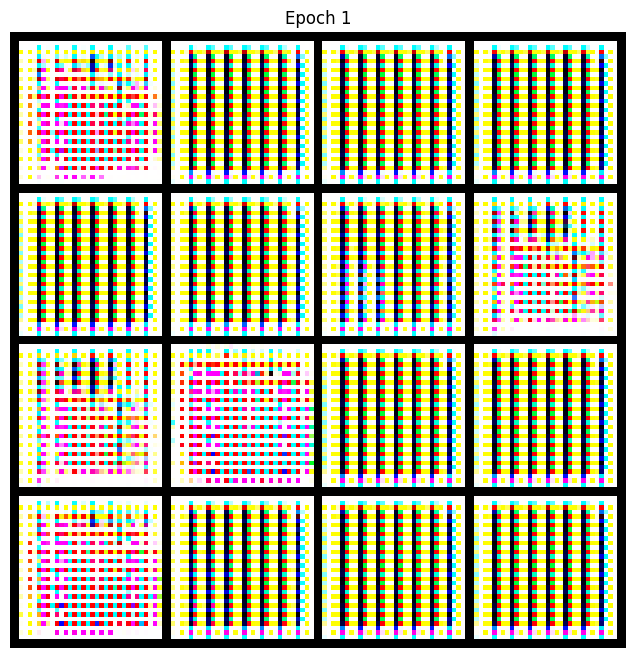

In [ ]:

import os
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import requests
import zipfile
import matplotlib.pyplot as plt

def try_gpu(i=0):
    return torch.device(f'cuda:{i}') if torch.cuda.device_count() > i else torch.device('cpu')

def download(url, cache_dir='data'):

    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if not os.path.exists(fname):
        print(f"Downloading from {url}...")
        r = requests.get(url, stream=True)
        with open(fname, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024):
                if chunk:
                    f.write(chunk)
        print("Download completed.")
    else:
        print(f"File {fname} already exists. Skipping download.")
    return fname

def download_extract(url, folder=None):

    fname = download(url)
    base_dir = os.path.dirname(fname)
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall(base_dir)
    if folder:
        return os.path.join(base_dir, folder)
    return base_dir

class GenBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GenBasicBlock, self).__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels*2),
            nn.ReLU(True),
            nn.ConvTranspose2d(out_channels*2, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True)
        )
    def forward(self, x):
        return self.net(x)

class Generator(nn.Module):
    def __init__(self, latent_dim=120, n_g=40):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            GenBasicBlock(latent_dim, n_g*4),
            GenBasicBlock(n_g*4, n_g*2),
            GenBasicBlock(n_g*2, n_g),
            GenBasicBlock(n_g, n_g//2),
            nn.ConvTranspose2d(n_g//2, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x)

class DiscBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DiscBasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.relu1 = nn.ReLU(True)
        self.split = out_channels // 2
        self.conv_left = nn.Conv2d(self.split, self.split, kernel_size=3, stride=2, padding=1)
        self.relu_left = nn.ReLU(True)
        self.conv_right = nn.Conv2d(self.split, self.split, kernel_size=3, stride=2, padding=1)
        self.relu_right = nn.ReLU(True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn = nn.BatchNorm2d(out_channels)
    def forward(self, x):
        x = self.relu1(self.conv1(x))
        left = x[:, :self.split, :, :]
        right = x[:, self.split:, :, :]
        left = self.relu_left(self.conv_left(left))
        right = self.relu_right(self.conv_right(right))
        x = torch.cat([left, right], dim=1)
        x = self.conv2(x)
        x = self.bn(x)
        return x

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            DiscBasicBlock(3, 32),
            DiscBasicBlock(32, 32),
            nn.Conv2d(32, 1, kernel_size=8, stride=1, padding=0)
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

def train_dcgan():
    device = try_gpu()
    print(f"Using device: {device}")

    data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/pokemon.zip', 'pokemon')

    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    dataset = torchvision.datasets.ImageFolder(
        data_dir,
        transform=transform
    )
    data_iter = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2)

    latent_dim = 120
    n_g = 40
    lr = 0.05
    num_epochs = 1

    net_G = Generator(latent_dim=latent_dim, n_g=n_g).to(device)
    net_D = Discriminator().to(device)

    criterion = nn.BCEWithLogitsLoss()

    opt_G = torch.optim.Adam(net_G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(net_D.parameters(), lr=lr, betas=(0.5, 0.999))

    for epoch in range(num_epochs):
        for X, _ in data_iter:
            bs = X.size(0)
            real_X = X.to(device)
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            opt_D.zero_grad()
            outputs_real = net_D(real_X)
            loss_real = criterion(outputs_real, real_labels)

            z = torch.randn(bs, latent_dim, 1, 1, device=device)
            fake_X = net_G(z)
            outputs_fake = net_D(fake_X.detach())
            loss_fake = criterion(outputs_fake, fake_labels)

            loss_D = (loss_real + loss_fake) / 2
            loss_D.backward()
            opt_D.step()

            opt_G.zero_grad()
            outputs_fake_for_G = net_D(fake_X)
            loss_G = criterion(outputs_fake_for_G, real_labels)
            loss_G.backward()
            opt_G.step()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

        if (epoch+1) % 5 == 0 or epoch == 0:
            with torch.no_grad():
                z = torch.randn(16, latent_dim, 1, 1, device=device)
                fake_images = net_G(z).cpu()
                grid = torchvision.utils.make_grid(fake_images, nrow=4, normalize=True)
                plt.figure(figsize=(8,8))
                plt.imshow(grid.permute(1, 2, 0))
                plt.title(f"Epoch {epoch+1}")
                plt.axis('off')
                plt.show()

if __name__ == "__main__":
    train_dcgan()


# EX 5

In [ ]:

import av
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import random_split, DataLoader
from torch.optim.lr_scheduler import StepLR
import torchvision
from torchvision import transforms
import os
import warnings

torch.manual_seed(42)
warnings.filterwarnings('ignore')

!pip install av
!wget http://serre-lab.clps.brown.edu/wp-content/uploads/2013/10/hmdb51_org.rar
!wget http://serre-lab.clps.brown.edu/wp-content/uploads/2013/10/test_train_splits.rar
!mkdir -p video_data test_train_splits
!unrar e test_train_splits.rar test_train_splits
!rm test_train_splits.rar
!unrar e hmdb51_org.rar
!rm hmdb51_org.rar
!mv *.rar video_data
for files in os.listdir('video_data'):
    foldername = files.split('.')[0]
    os.system("mkdir -p video_data/" + foldername)
    os.system("unrar e video_data/"+ files + " video_data/" + foldername)
!rm video_data/*.rar

val_split = 0.05
num_frames = 16
clip_steps = 50
num_workers = 8
bs = 4

train_tfms = transforms.Compose([
    transforms.Lambda(lambda x: x.permute(3, 0, 1, 2).float() / 255.),
    transforms.Resize((128, 171)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop((112, 112))
])
test_tfms = transforms.Compose([
    transforms.Lambda(lambda x: x.permute(3, 0, 1, 2).float() / 255.),
    transforms.Resize((128, 171)),
    transforms.CenterCrop((112, 112))
])

hmdb51_train = torchvision.datasets.HMDB51(
    'video_data/', 'test_train_splits/', num_frames, step_between_clips=clip_steps,
    fold=1, train=True, transform=train_tfms, num_workers=num_workers
)
hmdb51_test = torchvision.datasets.HMDB51(
    'video_data/', 'test_train_splits/', num_frames, step_between_clips=clip_steps,
    fold=1, train=False, transform=test_tfms, num_workers=num_workers
)

total_train_samples = len(hmdb51_train)
total_val_samples = round(val_split * total_train_samples)
hmdb51_train_v1, hmdb51_val_v1 = random_split(
    hmdb51_train, [total_train_samples - total_val_samples, total_val_samples]
)

train_loader = DataLoader(hmdb51_train_v1, batch_size=bs, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(hmdb51_val_v1,   batch_size=bs, shuffle=True, num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(hmdb51_test,     batch_size=bs, shuffle=False, num_workers=num_workers, pin_memory=True)

def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

class Inc(nn.Module):
    def __init__(self):
        super(Inc, self).__init__()
        self.conv1 = nn.Conv3d(32, 32, kernel_size=1)
        self.conv2 = nn.Conv3d(32, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv3d(96, 32, kernel_size=1)
    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv1(x)
        x3 = self.conv1(x)
        x2_1 = self.conv2(x2)
        x3_1 = self.conv2(x3)
        x4 = torch.cat([x1, x2_1, x3_1], dim=1)
        x4 = self.conv3(x4)
        return x4

class InceptionBlock(nn.Module):
    def __init__(self):
        super(InceptionBlock, self).__init__()
        self.conv1 = nn.Conv3d(3, 32, kernel_size=7, stride=1, padding=3)
        self.conv2 = nn.Conv3d(32, 32, kernel_size=1, stride=1, padding=1)
        self.conv3 = nn.Conv3d(32, 32, kernel_size=3, padding=1, stride=1)
        self.inc = Inc()
        self.conv4 = nn.Conv3d(32, 32, kernel_size=1, stride=1, padding=1)
        self.adaptive_avgpool = nn.AdaptiveAvgPool3d((1,1,1))
        self.bn = nn.BatchNorm3d(32)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(32, 101)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        for _ in range(9):
            x = self.inc(x)
        x = self.conv4(x)
        x = self.adaptive_avgpool(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.fc(x.view(x.size(0), -1))
        return x

model = InceptionBlock()

def train(model, loader, optimizer, epoch, device=try_gpu()):
    model.train()
    model = model.to(device)
    total_loss, total_correct, num_labels = 0, 0, 0
    for batch_id, data in enumerate(loader):
        data, target = data[0], data[-1]
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        num_labels += data.size(0)
        pred = output.argmax(dim=1, keepdim=True)
        total_correct += pred.eq(target.view_as(pred)).sum().item()
        if (batch_id + 1) % 100 == 0:
            print('Train Epoch: {} Batch [{}/{} ({:.0f}%)] Loss: {:.6f} Accuracy: {}/{} ({:.0f}%)'.format(
                epoch, (batch_id + 1) * len(data), len(loader.dataset),
                100. * (batch_id + 1) / len(loader),
                total_loss / num_labels, total_correct, num_labels,
                100. * total_correct / num_labels
            ))
    print('Train Epoch: {} Average Loss: {:.6f} Average Accuracy: {}/{} ({:.0f}%)'.format(
         epoch, total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

def test(model, loader, text='Validation', device=try_gpu()):
    model.eval()
    model = model.to(device)
    total_loss, total_correct, num_labels = 0, 0, 0
    with torch.no_grad():
        for batch_id, data in enumerate(loader):
            data, target = data[0], data[-1]
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = F.cross_entropy(output, target)
            total_loss += loss.item()
            num_labels += data.size(0)
            pred = output.argmax(dim=1, keepdim=True)
            total_correct += pred.eq(target.view_as(pred)).sum().item()
    print(text + ' Average Loss: {:.6f} Average Accuracy: {}/{} ({:.0f}%)'.format(
         total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

lr = 1e-2
gamma = 0.7
total_epochs = 1
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, total_epochs + 1):
    train(model, train_loader, optimizer, epoch)
    test(model, val_loader, text="Validation")
    scheduler.step()


ERROR: Operation cancelled by user
--2025-01-15 17:38:13--  http://serre-lab.clps.brown.edu/wp-content/uploads/2013/10/hmdb51_org.rar
Resolving serre-lab.clps.brown.edu (serre-lab.clps.brown.edu)... 128.148.254.114
Connecting to serre-lab.clps.brown.edu (serre-lab.clps.brown.edu)|128.148.254.114|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://serre-lab.clps.brown.edu/wp-content/uploads/2013/10/hmdb51_org.rar [following]
--2025-01-15 17:38:14--  https://serre-lab.clps.brown.edu/wp-content/uploads/2013/10/hmdb51_org.rar
Connecting to serre-lab.clps.brown.edu (serre-lab.clps.brown.edu)|128.148.254.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2124008126 (2.0G)
Saving to: ‘hmdb51_org.rar’

hmdb51_org.rar        0%[                    ]  88.00K   133KB/s               ^C
--2025-01-15 17:38:16--  http://serre-lab.clps.brown.edu/wp-content/uploads/2013/10/test_train_splits.rar
Resolving serre-lab.clps.brown.edu (serre-lab.c

  0%|          | 0/423 [00:00<?, ?it/s]


ImportError: Caught ImportError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/usr/local/lib/python3.10/dist-packages/torchvision/datasets/video_utils.py", line 63, in __getitem__
    return read_video_timestamps(self.video_paths[idx])
  File "/usr/local/lib/python3.10/dist-packages/torchvision/io/video.py", line 414, in read_video_timestamps
    _check_av_available()
  File "/usr/local/lib/python3.10/dist-packages/torchvision/io/video.py", li